# C51: project a return distribution onto fixed atoms

C51 represents $Z(s,a)$ with probabilities $p_i$ on fixed atoms $z_i$. It minimizes
$$\mathcal L=-\sum_i(\Phi TZ)_i\log p_i(s,a),$$
where $TZ$ is the Bellman-updated distribution and $\Phi$ projects it back onto the fixed support. This notebook implements that projection and cross-entropy directly.

## 1. Define the categorical support

The network outputs one logit for every action-atom pair; softmax converts logits into distributions.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

ATOMS = 51
V_MIN, V_MAX = -10.0, 10.0
GAMMA = 0.99
support = torch.linspace(V_MIN, V_MAX, ATOMS)

class CategoricalNetwork(nn.Module):
    def __init__(self, observations=4, actions=2):
        super().__init__()
        self.actions = actions
        self.model = nn.Sequential(nn.Linear(observations, 64), nn.ReLU(), nn.Linear(64, actions * ATOMS))
    def forward(self, observations):
        logits = self.model(observations).view(-1, self.actions, ATOMS)
        return logits.softmax(dim=-1)

network = CategoricalNetwork()
optimizer = torch.optim.Adam(network.parameters(), lr=1e-3)

## 2. Project Bellman-shifted atoms

Each shifted atom distributes its probability between the two nearest support locations.

In [2]:
def project_distribution(next_probabilities, rewards, terminals):
    batch = len(rewards)
    shifted = rewards[:, None] + GAMMA * (1 - terminals[:, None]) * support[None, :]
    shifted = shifted.clamp(V_MIN, V_MAX)
    positions = (shifted - V_MIN) / ((V_MAX - V_MIN) / (ATOMS - 1))
    lower, upper = positions.floor().long(), positions.ceil().long()
    projected = torch.zeros_like(next_probabilities)
    for row in range(batch):
        for atom in range(ATOMS):
            probability = next_probabilities[row, atom]
            lo, hi, position = lower[row, atom], upper[row, atom], positions[row, atom]
            if lo == hi:
                projected[row, lo] += probability
            else:
                projected[row, lo] += probability * (hi - position)
                projected[row, hi] += probability * (position - lo)
    return projected

next_probabilities = torch.full((2, ATOMS), 1 / ATOMS)
target = project_distribution(next_probabilities, torch.tensor([1.0, -1.0]), torch.tensor([0.0, 1.0]))
assert torch.allclose(target.sum(1), torch.ones(2))

## 3. Optimize and inspect distributions

Cross-entropy moves the predicted probabilities toward the projected targets.

/home/pablo/workspace/AprendeRL/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:484: UserWarning: Found GPU0 NVIDIA GeForce GTX 960M which is of compute capability (CC) 5.0.
The following list shows the CCs this version of PyTorch was built for and the hardware CCs it supports:
- 7.5 which supports hardware CC >=7.5,<8.0
- 8.0 which supports hardware CC >=8.0,<9.0 except {8.7}
- 8.6 which supports hardware CC >=8.6,<9.0 except {8.7}
- 9.0 which supports hardware CC >=9.0,<10.0
- 10.0 which supports hardware CC >=10.0,<11.0 except {10.1}
- 12.0 which supports hardware CC >=12.0,<13.0
Your installed torch==2.14.0+cu130 does not include kernels for this GPU. Reinstall the same version against a CUDA build that does, e.g.:
  For CUDA 12.6 use pip install torch==2.14.0 --index-url https://download.pytorch.org/whl/cu126
  _warn_unsupported_code(d, device_cc, code_ccs)
/home/pablo/workspace/AprendeRL/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:602: UserWarning: 
NVIDIA

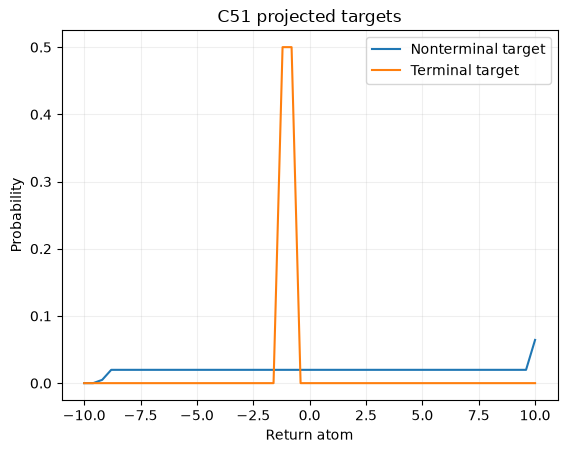

In [3]:
observations = torch.randn(2, 4)
actions = torch.tensor([0, 1])
predicted = network(observations)[torch.arange(2), actions]
loss = -(target * predicted.clamp_min(1e-6).log()).sum(1).mean()
optimizer.zero_grad(); loss.backward(); optimizer.step()
plt.plot(support, target[0], label="Nonterminal target")
plt.plot(support, target[1], label="Terminal target")
plt.xlabel("Return atom")
plt.ylabel("Probability")
plt.title("C51 projected targets")
plt.legend(); plt.grid(alpha=0.2); plt.show()